# 03 — Hyperparameter tuning with expanding time folds

This notebook builds every fold, candidate model, pooled threshold, and cost metric explicitly. `FAST_MODE` keeps interactive runs short; disabling it uses all rows and the configured 12/30 candidate budgets.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FAST_MODE = True
SEED = 42
COST_RATIO = 5
DATE = "deployment_date"
OUTCOME = "deployment_outcome"
LABEL = "deployment_risk"
IDS = ["deployment_id", "device_id", "site_id", "firmware_fingerprint"]
LEAKAGE = ["time_to_failure_hours", "rollback_required"]
CATEGORICAL = ["vendor_name", "device_type", "hardware_series", "fleet_tier", "site_criticality", "deployment_type"]
NUMERIC = ["version_jump_magnitude", "kernel_touched", "bootloader_touched", "protocol_mismatch_flag", "maintenance_window", "network_stress_score", "error_rate_predeploy", "uptime_days", "past_failure_count", "firmware_release_age_days", "cve_count", "max_cvss_score", "cross_vendor_dependency_count", "dependent_device_count"]
DERIVED = ["major_version_jump", "major_version_changed", "emergency_no_maintenance", "core_system_touched"]
MODEL_NUMERIC = NUMERIC + DERIVED

config = yaml.safe_load((ROOT / "config.yaml").read_text(encoding="utf-8"))
raw = pd.read_csv(ROOT / "data" / "deployment_events.csv")
assert set(raw[OUTCOME].dropna()).issubset({"SUCCESS", "DEGRADED", "ROLLBACK", "FAILED"})
assert not raw["deployment_id"].duplicated().any()
raw[DATE] = pd.to_datetime(raw[DATE], errors="coerce")
assert raw[DATE].notna().all()
for column in NUMERIC:
    before = raw[column].notna()
    raw[column] = pd.to_numeric(raw[column], errors="coerce")
    assert not (before & raw[column].isna()).any(), column

## Repeat the feature formulas explicitly

In [2]:
def major(value):
    try:
        return int(str(value).split(".", 1)[0])
    except (TypeError, ValueError):
        return np.nan

featured = raw.copy()
current_major = featured["current_firmware"].map(major)
target_major = featured["target_firmware"].map(major)
assert (current_major.isna() | target_major.isna()).mean() <= 0.01
featured["major_version_jump"] = target_major - current_major
featured["major_version_changed"] = np.where(featured["major_version_jump"].isna(), np.nan, featured["major_version_jump"].ne(0).astype(int))
featured["emergency_no_maintenance"] = (featured["deployment_type"].eq("EMERGENCY") & featured["maintenance_window"].eq(0)).astype(int)
featured["core_system_touched"] = (featured["kernel_touched"].fillna(0).ne(0) | featured["bootloader_touched"].fillna(0).ne(0)).astype(int)
featured[LABEL] = featured[OUTCOME].ne("SUCCESS").astype(int)
deployment_ids = featured["deployment_id"].copy()
featured = featured.drop(columns=IDS + LEAKAGE + ["current_firmware", "target_firmware"])
featured.index = pd.Index(deployment_ids, name="deployment_id")
featured = featured.sort_values(DATE, kind="mergesort")
if FAST_MODE:
    featured = featured.iloc[:5000].copy()
print(f"tuning source rows={len(featured):,}")

tuning source rows=5,000


## Outer split and expanding folds

The latest 20% is held out from tuning. Inside the earlier data, each fold expands its training history and validates on the next contiguous date block.

In [3]:
outer_position = min(max(int(np.floor(len(featured) * 0.8)), 1), len(featured) - 1)
outer_cutoff = featured[DATE].iloc[outer_position]
tuning_source = featured.loc[featured[DATE] < outer_cutoff].copy()
holdout = featured.loc[featured[DATE] >= outer_cutoff].copy()

fold_count = 2 if FAST_MODE else int(config["tuning"]["cv_folds"])
initial_quantile = 0.5 if FAST_MODE else float(config["tuning"]["initial_train_quantile"])
unique_dates = np.array(sorted(pd.unique(tuning_source[DATE])))
initial_date_count = max(int(np.floor(len(unique_dates) * initial_quantile)), 1)
validation_date_chunks = np.array_split(unique_dates[initial_date_count:], fold_count)
fold_frames = []
for number, date_chunk in enumerate(validation_date_chunks, start=1):
    cutoff = pd.Timestamp(date_chunk[0])
    fold_train = tuning_source.loc[tuning_source[DATE] < cutoff].copy()
    fold_validation = tuning_source.loc[tuning_source[DATE].isin(date_chunk)].copy()
    assert fold_train[DATE].max() < fold_validation[DATE].min()
    fold_frames.append((number, cutoff, fold_train, fold_validation))

pd.DataFrame([{
    "fold": number,
    "cutoff": cutoff,
    "train_rows": len(train),
    "validation_rows": len(validation),
    "train_end": train[DATE].max(),
    "validation_start": validation[DATE].min(),
} for number, cutoff, train, validation in fold_frames])

,fold,cutoff,train_rows,validation_rows,train_end,validation_start
0,1,2020-06-21,935,1211,2020-06-20,2020-06-21
1,2,2020-11-27,2146,1843,2020-11-26,2020-11-27


## Fit fold-specific preprocessing

Every fold gets independent medians, category vocabulary, and scaler fitted only on that fold's historical rows.

In [4]:
def prepare_fold(number, cutoff, train, validation):
    drop = [DATE, OUTCOME, LABEL]
    train_raw = train.drop(columns=drop)
    validation_raw = validation.drop(columns=drop)
    medians = train_raw[MODEL_NUMERIC].astype(float).median()
    train_numeric = train_raw[MODEL_NUMERIC].astype(float).fillna(medians)
    validation_numeric = validation_raw[MODEL_NUMERIC].astype(float).fillna(medians)

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    train_encoded_values = encoder.fit_transform(train_raw[CATEGORICAL])
    validation_encoded_values = encoder.transform(validation_raw[CATEGORICAL])
    names = encoder.get_feature_names_out(CATEGORICAL).tolist()
    train_encoded = pd.DataFrame(train_encoded_values, columns=names, index=train.index)
    validation_encoded = pd.DataFrame(validation_encoded_values, columns=names, index=validation.index)
    feature_list = MODEL_NUMERIC + names
    X_train = pd.concat([train_numeric, train_encoded], axis=1).reindex(columns=feature_list, fill_value=0.0)
    X_validation = pd.concat([validation_numeric, validation_encoded], axis=1).reindex(columns=feature_list, fill_value=0.0)

    scaler = StandardScaler()
    X_train.loc[:, MODEL_NUMERIC] = scaler.fit_transform(X_train[MODEL_NUMERIC])
    X_validation.loc[:, MODEL_NUMERIC] = scaler.transform(X_validation[MODEL_NUMERIC])
    return {
        "number": number,
        "cutoff": cutoff,
        "X_train": X_train.astype(float),
        "y_train": train[LABEL].astype(int).to_numpy(),
        "X_validation": X_validation.astype(float),
        "y_validation": validation[LABEL].astype(int).to_numpy(),
    }

folds = [prepare_fold(*fold) for fold in fold_frames]
[(fold["number"], fold["X_train"].shape, fold["X_validation"].shape) for fold in folds]

[(1, (935, 85), (1211, 85)), (2, (2146, 85), (1843, 85))]

## Candidate sampling and pooled cost threshold

In [5]:
def build_model(family, params):
    if family == "logistic":
        return LogisticRegression(C=float(params["C"]), max_iter=int(params["max_iter"]), class_weight=params.get("class_weight"), random_state=SEED)
    return XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=1,
        verbosity=0,
    )

def choose_threshold(labels, probabilities):
    rows = []
    for index in range(1, 100):
        threshold = index / 100
        predictions = probabilities >= threshold
        fn = int(((predictions == 0) & (labels == 1)).sum())
        fp = int(((predictions == 1) & (labels == 0)).sum())
        rows.append((threshold, fn * COST_RATIO + fp, fn, fp))
    return min(rows, key=lambda row: (row[1], row[0]))

def candidate_metrics(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    fn = int(((predictions == 0) & (labels == 1)).sum())
    fp = int(((predictions == 1) & (labels == 0)).sum())
    return {
        "expected_cost": fn * COST_RATIO + fp,
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "precision": float(precision_score(labels, predictions, zero_division=0)),
        "recall": float(recall_score(labels, predictions, zero_division=0)),
        "f1": float(f1_score(labels, predictions, zero_division=0)),
    }

budgets = {"logistic": 2, "xgboost": 3} if FAST_MODE else config["tuning"]["max_candidates"]
candidates = {}
for offset, family in enumerate(["logistic", "xgboost"]):
    space = config["tuning"]["search_spaces"][family]
    total = int(np.prod([len(values) for values in space.values()]))
    candidates[family] = list(ParameterSampler(space, n_iter=min(int(budgets[family]), total), random_state=SEED + offset * 10000))
sum(len(values) for values in candidates.values())

5

In [6]:
results = []
trial = 0
for family, parameter_sets in candidates.items():
    for params in parameter_sets:
        trial += 1
        labels_by_fold = []
        probabilities_by_fold = []
        for fold in folds:
            model = build_model(family, params)
            model.fit(fold["X_train"].to_numpy(), fold["y_train"])
            probabilities = model.predict_proba(fold["X_validation"].to_numpy())[:, 1]
            labels_by_fold.append(fold["y_validation"])
            probabilities_by_fold.append(probabilities)

        pooled_labels = np.concatenate(labels_by_fold)
        pooled_probabilities = np.concatenate(probabilities_by_fold)
        threshold, expected_cost, _, _ = choose_threshold(pooled_labels, pooled_probabilities)
        metrics = candidate_metrics(pooled_labels, pooled_probabilities, threshold)
        fold_costs = [candidate_metrics(labels, probabilities, threshold)["expected_cost"] for labels, probabilities in zip(labels_by_fold, probabilities_by_fold)]
        results.append({
            "trial": trial,
            "family": family,
            "params": json.dumps(params, sort_keys=True),
            "threshold": threshold,
            "fold_costs": json.dumps(fold_costs),
            **metrics,
        })
        print(f"trial={trial:02d} family={family:8s} cost={expected_cost:5.0f} auc={metrics['roc_auc']:.4f} threshold={threshold:.2f}")

results = pd.DataFrame(results).sort_values(["expected_cost", "roc_auc"], ascending=[True, False]).reset_index(drop=True)
display(results)

trial=01 family=logistic cost= 1631 auc=0.7030 threshold=0.28


trial=02 family=logistic cost= 1633 auc=0.6889 threshold=0.01


trial=03 family=xgboost  cost= 1627 auc=0.6762 threshold=0.04


trial=04 family=xgboost  cost= 1633 auc=0.6957 threshold=0.01


trial=05 family=xgboost  cost= 1632 auc=0.6842 threshold=0.07


,trial,family,params,threshold,fold_costs,expected_cost,roc_auc,precision,recall,f1
0,3,xgboost,"{""colsample_bytree"": 0.65, ""gamma"": 0.5, ""lear...",0.04,"[631, 996]",1627,0.676225,0.466207,1.0,0.635936
1,1,logistic,"{""C"": 0.001, ""class_weight"": null, ""max_iter"":...",0.28,"[636, 995]",1631,0.703033,0.465596,1.0,0.635368
2,5,xgboost,"{""colsample_bytree"": 0.65, ""gamma"": 0.5, ""lear...",0.07,"[636, 996]",1632,0.684182,0.465444,1.0,0.635226
3,4,xgboost,"{""colsample_bytree"": 1.0, ""gamma"": 0.1, ""learn...",0.01,"[636, 997]",1633,0.695733,0.465291,1.0,0.635084
4,2,logistic,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_it...",0.01,"[636, 997]",1633,0.688862,0.465291,1.0,0.635084


## Persist the transparent tuning table

Notebook 4 reads the best candidate from each family. The CSV keeps every parameter set, pooled metric, decision threshold, and fold-cost vector visible.

C:\Users\pmkul\Downloads\FirmAware\notebook_runs\tuning\tuning_results.csv


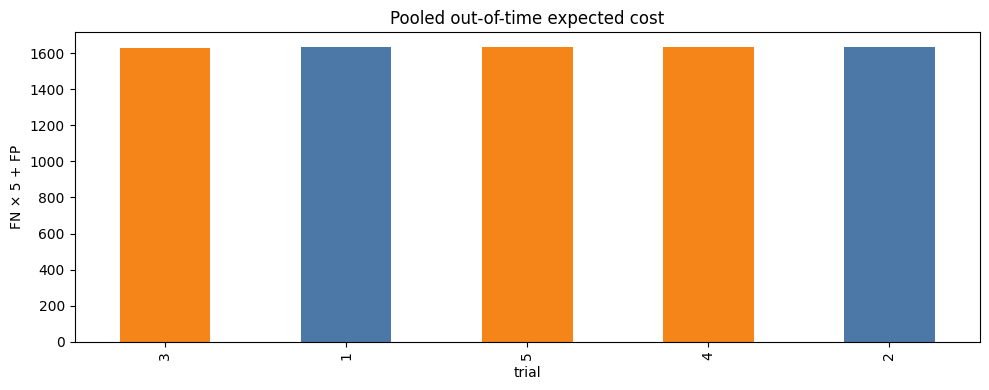

In [7]:
output_dir = ROOT / "notebook_runs" / "tuning"
output_dir.mkdir(parents=True, exist_ok=True)
results.to_csv(output_dir / "tuning_results.csv", index=False)
best_by_family = results.sort_values(["expected_cost", "roc_auc"], ascending=[True, False]).groupby("family", as_index=False).first()
best_by_family.to_json(output_dir / "best_by_family.json", orient="records", indent=2)

ax = results.sort_values("expected_cost").plot.bar(x="trial", y="expected_cost", color=results.sort_values("expected_cost")["family"].map({"logistic": "#4C78A8", "xgboost": "#F58518"}), figsize=(10, 4), legend=False)
ax.set_title("Pooled out-of-time expected cost")
ax.set_ylabel("FN × 5 + FP")
plt.tight_layout()
print(output_dir / "tuning_results.csv")